In [3]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
from pythainlp import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import os

train_df = pd.read_csv('train_data.csv')

# ตัดคำ
train_df['Tokens'] = train_df['Text'].apply(lambda x: word_tokenize(str(x), engine='newmm'))

# สร้าง Tokenizer
vocab_size = 5000 
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(train_df['Tokens'])

# แปลงคำศัพท์เป็น index และทำ Padding
max_len = 70  # 
train_sequences = tokenizer.texts_to_sequences(train_df['Tokens'])
X_train = pad_sequences(train_sequences, maxlen=max_len, padding='post')
y_train = train_df['Label'].values

#Validation set
val_df = pd.read_csv('val_data.csv')

val_df['Tokens'] = val_df['Text'].apply(lambda x: word_tokenize(str(x), engine='newmm'))
val_sequences = tokenizer.texts_to_sequences(val_df['Tokens'])

X_val = pad_sequences(val_sequences, maxlen=max_len, padding='post')
y_val = val_df['Label'].values

print(f"Validation set shape: {X_val.shape}")
 
print(f"Train set shape: {X_train.shape}")

data_path = '../data/'

np.save(os.path.join(data_path, 'X_val.npy'), X_val)    
np.save(os.path.join(data_path, 'y_val.npy'), y_val)

print("บันทึก X_train และ y_train เ")

KeyboardInterrupt: 

In [ ]:
# Test set

import pandas as pd
from pythainlp import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

test_df = pd.read_csv('test_data.csv')

# ตัดคำ
test_df['Tokens'] = test_df['Text'].apply(lambda x: word_tokenize(str(x), engine='newmm'))

# สร้าง Tokenizer
vocab_size = 5000 
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(test_df['Tokens'])

# แปลงคำศัพท์เป็น index และทำ Padding
max_len = 70  # 
train_sequences = tokenizer.texts_to_sequences(test_df['Tokens'])
X_train = pad_sequences(train_sequences, maxlen=max_len, padding='post')
y_train = test_df['Label'].values

In [3]:
print(train_sequences)

[[614, 92, 33, 9, 2, 5, 11, 173, 102, 21, 615, 2, 777, 2, 10], [262, 1181, 1182, 1183, 1184, 778, 354, 8, 1185, 80, 1186, 392, 2, 17, 2, 1187, 1188, 1189, 75, 779, 1190, 2, 3, 1191], [88, 12, 46, 32, 2, 4, 246, 393, 780, 2, 511, 1192, 512, 1193, 781, 513, 1194, 511, 2, 65, 1195, 13, 1196, 263, 2, 220, 157, 1197, 12, 46, 32, 2, 7, 2, 3, 1198], [122, 247, 782, 2, 264, 2, 1199, 2, 248, 34, 2, 514, 2, 14, 2, 81, 394, 616, 321, 2, 115, 189, 70, 2, 783, 2, 14, 2, 140, 617, 618, 2, 93, 174, 6, 1200, 619, 2, 116, 141, 322, 2, 7, 9, 2, 3, 1201], [12, 53, 76, 55, 395, 2, 49, 283, 158, 2, 38, 2, 10, 2, 115, 2, 111, 2, 12, 53, 2, 76, 55, 11, 18, 249, 2, 323, 103, 441, 323, 620, 441, 2, 621, 2, 442, 30, 2, 13, 2, 621, 2, 159, 30, 2, 6, 12, 46, 32, 7, 2, 3, 1202], [1203, 2, 89, 5, 2, 157, 142, 117, 18, 11, 143, 2, 784, 34, 2, 62, 47], [284, 1204, 1205, 2, 622, 355, 785, 2, 1206, 2, 11, 515, 786, 2, 77, 1207, 623, 2, 6, 787, 129, 250, 1208, 2, 17, 2, 199, 30, 13, 94, 232, 30, 2, 78, 7, 25, 3, 1209], 

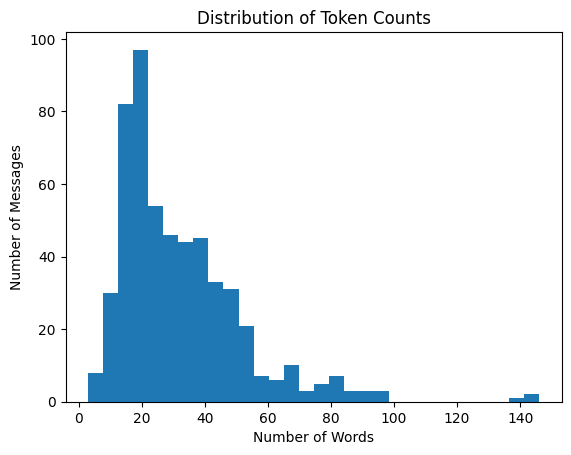

In [4]:
import matplotlib.pyplot as plt

token_counts = train_df['Tokens'].apply(len)
plt.hist(token_counts, bins=30)
plt.title('Distribution of Token Counts')
plt.xlabel('Number of Words')
plt.ylabel('Number of Messages')
plt.show()

In [ ]:
print(train_df['Tokens'].apply(len).quantile(0.95))

NameError: name 'train_df' is not defined

In [2]:
print(train_df[['Text', 'Tokens']].head())
print(f"ตัวอย่างการตัดคำแถวที่ 1: {train_df['Tokens'].iloc[0]}")

                                                Text  \
0  ิยินดีด้วย! คุณได้รับเงินคืนจากกองทุน 1,000,00...   
1  สมัคຣสมๅชิกรับฟรีสปิuທັuที 1 เกມส์\r\nคลิ๊ກ ht...   
2  ลูกค้าทรูไอดี รับชมซีรีส์จีน 'เล่ห์รักวังคุนหน...   
3  ประกันสุขภาพเหมาจ่าย AIA HealthSaver คุ้มครองส...   
4  ทรูพอยท์แลกลุ้นรวย แจกใหญ่ทอง 5 บาท เริ่ม 9 ทร...   

                                              Tokens  
0  [ิ, ยินดี, ด้วย, !,  , คุณ, ได้, รับเงิน, คืน,...  
1  [ส, มัค, ຣ, สม, ๅ, ชิ, กรับ, ฟรี, สปิ, u, ທັu,...  
2  [ลูกค้า, ทรู, ไอ, ดี,  , รับ, ชม, ซีรีส์, จีน,...  
3  [ประกัน, สุขภาพ, เหมาจ่าย,  , AIA,  , HealthSa...  
4  [ทรู, พอยท์, แลก, ลุ้น, รวย,  , แจก, ใหญ่, ทอง...  
ตัวอย่างการตัดคำแถวที่ 1: ['ิ', 'ยินดี', 'ด้วย', '!', ' ', 'คุณ', 'ได้', 'รับเงิน', 'คืน', 'จาก', 'กองทุน', ' ', '1,000,000', ' ', 'บาท']


BASELINE--run

In [2]:
import pandas as pd
import re
from pythainlp import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import f1_score, confusion_matrix

train_df = pd.read_csv('train_data.csv')
val_df = pd.read_csv('val_data.csv')

X_train, y_train = train_df['Text'], train_df['Label'].values
X_test, y_test = val_df['Text'], val_df['Label'].values

def custom_thai_tokenizer(text):
    text = str(text)
    text = re.sub(r'[\u200b\u200c\u200d\ufeff]', '', text)
    return word_tokenize(text, engine='newmm')

tfidf = TfidfVectorizer(
    tokenizer=custom_thai_tokenizer, 
    token_pattern=None, 
    max_features=5000
)

pipeline_logis = Pipeline([
    ('vectorizer', tfidf),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_svm = Pipeline([
    ('vectorizer', tfidf),
    ('classifier', SVC(kernel='linear', C=1.0, random_state=42))
])

# เทรน SVM
print("\n โมเดล SVM")
pipeline_svm.fit(X_train, y_train)

y_pred_svm = pipeline_svm.predict(X_test)
print(f"\n[SVM] Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}")
print(classification_report(y_test, y_pred_svm, target_names=["Normal (0)", 'Scam (1)']))

# คำนวณและแสดงค่า F1-score, False Positive และ False Negative สำหรับ SVM
svm_f1 = f1_score(y_test, y_pred_svm, average='macro')
svm_cm = confusion_matrix(y_test, y_pred_svm)
svm_fp = svm_cm[0, 1]
svm_fn = svm_cm[1, 0]
print(f"[SVM] F1-Score: {svm_f1:.2f}")
print(f"[SVM] False Positives (FP): {svm_fp}")
print(f"[SVM] False Negatives (FN): {svm_fn}")

# เทรน Logistic Regression
print("\n โมเดล Logistic Regression")
pipeline_logis.fit(X_train, y_train)

y_pred_logis = pipeline_logis.predict(X_test)
print(f"\n[Logistic Regression] Accuracy: {accuracy_score(y_test, y_pred_logis):.2f}")
print(classification_report(y_test, y_pred_logis, target_names=['Normal (0)', "Scam (1)"]))

# คำนวณและแสดงค่า F1-score , False Positive และ False Negative สำหรับ Logistic Regression
logis_f1 = f1_score(y_test, y_pred_logis, average='macro')
logis_cm = confusion_matrix(y_test, y_pred_logis)
logis_fp = logis_cm[0, 1]
logis_fn = logis_cm[1, 0]
print(f"[Logistic Regression] F1-Score: {logis_f1:.2f}")
print(f"[Logistic Regression] False Positives (FP): {logis_fp}")
print(f"[Logistic Regression] False Negatives (FN): {logis_fn}")


 โมเดล SVM

[SVM] Accuracy: 0.93
              precision    recall  f1-score   support

  Normal (0)       0.93      0.93      0.93        58
    Scam (1)       0.93      0.93      0.93        58

    accuracy                           0.93       116
   macro avg       0.93      0.93      0.93       116
weighted avg       0.93      0.93      0.93       116

[SVM] F1-Score: 0.93
[SVM] False Positives (FP): 4
[SVM] False Negatives (FN): 4

 โมเดล Logistic Regression

[Logistic Regression] Accuracy: 0.92
              precision    recall  f1-score   support

  Normal (0)       0.90      0.95      0.92        58
    Scam (1)       0.95      0.90      0.92        58

    accuracy                           0.92       116
   macro avg       0.92      0.92      0.92       116
weighted avg       0.92      0.92      0.92       116

[Logistic Regression] F1-Score: 0.92
[Logistic Regression] False Positives (FP): 3
[Logistic Regression] False Negatives (FN): 6


In [4]:
# Test set

import pandas as pd
from pythainlp import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

test_df = pd.read_csv('test_data.csv')

# ตัดคำ
test_df['Tokens'] = test_df['Text'].apply(lambda x: word_tokenize(str(x), engine='newmm'))

# สร้าง Tokenizer
vocab_size = 5000 
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(test_df['Tokens'])

# แปลงคำศัพท์เป็น index และทำ Padding
max_len = 70  # 
train_sequences = tokenizer.texts_to_sequences(test_df['Tokens'])
X_train = pad_sequences(train_sequences, maxlen=max_len, padding='post')
y_train = test_df['Label'].values

In [6]:
import re
from pythainlp import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import f1_score, confusion_matrix

train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv')

X_train, y_train = train_df['Text'], train_df['Label'].values
X_test, y_test = test_df['Text'], test_df['Label'].values

def custom_thai_tokenizer(text):
    text = str(text)
    text = re.sub(r'[\u200b\u200c\u200d\ufeff]', '', text)
    return word_tokenize(text, engine='newmm')

tfidf = TfidfVectorizer(
    tokenizer=custom_thai_tokenizer, 
    token_pattern=None, 
    max_features=5000
)

pipeline_logis = Pipeline([
    ('vectorizer', tfidf),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_svm = Pipeline([
    ('vectorizer', tfidf),
    ('classifier', SVC(kernel='linear', C=1.0, random_state=42))
])

# เทรน SVM
print("\n โมเดล SVM")
pipeline_svm.fit(X_train, y_train)

y_pred_svm = pipeline_svm.predict(X_test)
print(f"\n[SVM] Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}")
print(classification_report(y_test, y_pred_svm, target_names=["Normal (0)", 'Scam (1)']))

# คำนวณและแสดงค่า F1-score, False Positive และ False Negative สำหรับ SVM
svm_f1 = f1_score(y_test, y_pred_svm, average='macro')
svm_cm = confusion_matrix(y_test, y_pred_svm)
svm_fp = svm_cm[0, 1]
svm_fn = svm_cm[1, 0]
print(f" F1-Score: {svm_f1:.2f}")
print(f" False Positives (FP): {svm_fp}")
print(f" False Negatives (FN): {svm_fn}")

# เทรน Logistic Regression
print("\n โมเดล Logistic Regression")
pipeline_logis.fit(X_train, y_train)

y_pred_logis = pipeline_logis.predict(X_test)
print(f"\n[Logistic Regression] Accuracy: {accuracy_score(y_test, y_pred_logis):.2f}")
print(classification_report(y_test, y_pred_logis, target_names=['Normal (0)', "Scam (1)"]))

# คำนวณและแสดงค่า F1-score , False Positive และ False Negative สำหรับ Logistic Regression
logis_f1 = f1_score(y_test, y_pred_logis, average='macro')
logis_cm = confusion_matrix(y_test, y_pred_logis)
logis_fp = logis_cm[0, 1]
logis_fn = logis_cm[1, 0]
print(f"F1-Score: {logis_f1:.2f}")
print(f"False Positives (FP): {logis_fp}")
print(f"False Negatives (FN): {logis_fn}")


 โมเดล SVM

[SVM] Accuracy: 0.91
              precision    recall  f1-score   support

  Normal (0)       0.93      0.90      0.91        58
    Scam (1)       0.90      0.93      0.92        58

    accuracy                           0.91       116
   macro avg       0.91      0.91      0.91       116
weighted avg       0.91      0.91      0.91       116

 F1-Score: 0.91
 False Positives (FP): 6
 False Negatives (FN): 4

 โมเดล Logistic Regression

[Logistic Regression] Accuracy: 0.90
              precision    recall  f1-score   support

  Normal (0)       0.91      0.88      0.89        58
    Scam (1)       0.88      0.91      0.90        58

    accuracy                           0.90       116
   macro avg       0.90      0.90      0.90       116
weighted avg       0.90      0.90      0.90       116

F1-Score: 0.90
False Positives (FP): 7
False Negatives (FN): 5


Val Test data prepocess code draft !!

In [9]:
val_df = pd.read_csv('val_data.csv')

val_df['Tokens'] = val_df['Text'].apply(lambda x: word_tokenize(str(x), engine='newmm'))
val_sequences = tokenizer.texts_to_sequences(val_df['Tokens'])

X_val = pad_sequences(val_sequences, maxlen=max_len, padding='post')
y_val = val_df['Label'].values

print(f"Validation set shape: {X_val.shape}")

Validation set shape: (116, 50)


In [24]:
print(val_df['Tokens'].apply(len).quantile(0.99))

86.69999999999999


In [ ]:
test_df = pd.read_csv('test.csv')
test_df['Tokens'] = test_df['Text'].apply(lambda x: word_tokenize(str(x), engine='newmm'))

test_sequences = tokenizer.texts_to_sequences(test_df['Tokens'])
X_test = pad_sequences(test_sequences, maxlen=max_len, padding='post')
y_test = test_df['Label'].values

print(f"Test set shape: {X_test.shape}")